# MVP Análise de Dados e Boas Práticas

**Nome:** Lucas Davi Santos Farias

**Matrícula:** 4052025002520

**Dataset:** [IA Jobs Market 2025 and 2026](https://www.kaggle.com/datasets/alitaqishah/ai-jobs-market-2025-2026-salaries)

# Descrição do Problema

Esse dataset possui um conjunto de dados de com 1500 anúncios de emprego nas áreas de IA e Machine Learning referentes ao período de 2025 e 2026, abrangendo 25 funções em 14 países. O dataset inclui salários, competências em alta, tendências de trabalho remoto e análises por tamanho de empresa. O objetivo principal é prever o salário baseado nas características fornecidas.

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

1. **É possível prever qual será o salário de um aplicante à vaga de emprego**

2. **Existe uma correlação entre o nível de experiência profissional e o salário?**

3. **Qual a média salarial dos anúncios por país?**

4. **Qual o salário médio para cada nível de educação mínimo requerido pelo anúncio?**

5. **Quais funções têm as maiores médias salarias?**

6. **Quais funções possuem as maiores médias salariais para anúncios Entry Level?**

7. **Quais países possuem o maior número de anúncios voltados a LLM?**

8. **Existe diferença de salário para cargos remotos e presenciais?**

9. **Ao longo do tempo existe uma tendência para uma maior proporção de anúncios de cargos de LLM?**

10. **Qual país possui a melhor razão entre salário e custo de vida?**

## Tipo de Problema

Este é um problema de **regressão supervisionada**. Dado um conjunto de dados, o objetivo é prever a qual o salário do anúncio.

## Seleção de Dados

O dataset IA Jobs Market é um conjunto de dados disponível no Kaggle com licença CC0: Public Domain com expectativa de atualização de dados "Annually". Não é necessária uma etapa de seleção de dados externa, pois o dataset já está curado e pronto para uso.

O dataset foi compilado a partir de fontes de dados públicos sobre salários (2025 - 2026):

Ravio Global Salary Benchmark 2026

Robert Half Technology Salary Guide 2026

Motion Recruitment AI/ML Salary Report 2025

LinkedIn Workforce Insights 2025-2026

Glassdoor AI Role Salary Data 2025

## Atributos do Dataset

O dataset IA Jobs Market contém 1.500 registros e possui 25 atributos:

- ***job_id*** (Identificador único para cada anúncio)
- ***job_title*** (Nome da função de IA ou ML (25 funções))
- ***job_category*** (Nome da categoria que a função se encaixa (AI Engineering, Data Science, MLOps...))
- ***experience_level*** (Experiência exigida)
- ***years_of_experience*** (Número mínimo de anos de experiência exigido)
- ***education_required*** (Educação mínima (Bachelor's / Master's / PhD / Bootcamp))
- ***annual_salary_usd*** (Salário anual em dólares)
- ***salary_min_usd*** (Valor mínimo da faixa salarial anunciada para esta função)
- ***salary_max_usd*** (Valor máximo da faixa salarial anunciada para esta função)
- ***city*** (Cidade onde a vaga está localizada)
- ***country*** (País onde a vaga está localizada)
- ***remote_work*** (On-site / Hybrid / Fully Remote)
- ***company_size*** (Tamanho da empresa: (Startup / SME / Mid-size / Enterprise / Big Tech))
- ***industry*** (Setor da indústria da vaga)
- ***required_skills*** (Habilidades exigidas para a vaga separada por "|")
- ***ia_salary_premium_pct*** (Porcentagem de prêmio salarial em comparação a uma função equivalente fora da área de IA)
- ***demand_score*** (Métrica que varia de 0 a 100 baseada no volume de contratações para a função anunciada)
- ***demand_growth*** (Porcentagem anual de crescimento na demanda por vaga)
- ***benefits_score_10*** (Qualidade dos benefícios oferecidos (0 a 10))
- ***posting_year*** (Ano em que o anúncio foi publicado)
- ***posting_month*** (Mês em que o anúncio foi publicado)
- ***is_senior*** (Se a vaga é para Sênior/Lead ou não)
- ***is_remote_friendly*** (1 se é híbrido ou completamente à distância. 0 se é em escritório)
- ***is_llm_role*** (Se é uma função que envolve LLMs)
- ***salary_tier*** (Salary bracket: Entry / Mid / Upper-Mid / Senior / Elite)

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset IA Jobs Market.

In [16]:
from dataclasses import dataclass

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/LucasDSF7/Data-Analysis-Puc-Rio/refs/heads/master/mvp/data/ai_jobs_market_2025_2026.csv')
df.head()

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset IA Jobs Market, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

O dataset IA Jobs Market possui 1.500 instâncias (observações) e 25 atributos. As caractéristicas variam entre o tipo numérico e categórica, com o atributo alvo sendo númerico contínuo, explicando o motivo do problema ser do tipo regressão supervisionada.

É possível observar que esse dataset não possui missings.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_id                 1500 non-null   object 
 1   job_title              1500 non-null   object 
 2   job_category           1500 non-null   object 
 3   experience_level       1500 non-null   object 
 4   years_of_experience    1500 non-null   int64  
 5   education_required     1500 non-null   object 
 6   annual_salary_usd      1500 non-null   float64
 7   salary_min_usd         1500 non-null   int64  
 8   salary_max_usd         1500 non-null   int64  
 9   city                   1500 non-null   object 
 10  country                1500 non-null   object 
 11  remote_work            1500 non-null   object 
 12  company_size           1500 non-null   object 
 13  industry               1500 non-null   object 
 14  required_skills        1500 non-null   object 
 15  ai_s

## Tratamento de Valores Nulos

Como mencionado, o dataset não possui missings. Podemos ter uma visualização utilizando o método isna() do pandas, somando todos os missings.

In [4]:
df.isna().sum().sum()

np.int64(0)

## Limpeza de Dados Redundantes

Alguns atributos são claramente derivados de outros atributos que agregam valor. Por exemplo:

- salary_min_usd e salary_max_usd são derivados da coluna annual_salary_usd.

- is_senior é uma coluna binária informando se experience_level é do tipo senior ou lead.

- is_remote_friendly é derivado do atributo remote_work.

- salary_tier é uma categorização de annual_salary_usd.

O atributo job_id também será descartado por se tratar de um indexador do anúncio, sem benefício para o modelo.

Além de descartar os atributos citados, também serão descartadas linhas duplicadas, se existirem.

Antes de tudo, como medida de boas práticas, será criado uma cópia do dataset originial, utilizando o método copy com parâmetro deep=True do Dataframe Pandas.

In [5]:
df_copy = df.copy(deep=True)

In [6]:
df_copy.drop(columns=['salary_min_usd', 'salary_max_usd', 'is_senior', 'is_remote_friendly', 'salary_tier', 'job_id'], inplace=True)
df_copy.drop_duplicates(inplace=True)

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [35]:
@dataclass
class HistogramConfig:
    sr: pd.Series
    bins: list[int]
    title: str
    x_label: str = ''
    y_label: str = 'Número de registros'


def numeric_feature_hist_box_plots(config: HistogramConfig) -> None:
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    # Fixing bins to later use in set_xticks method.
    ax[0].hist(config.sr, bins=config.bins)
    ax[0].set_xticks(config.bins)
    ax[0].set_title(config.title)
    ax[0].set_ylabel(config.y_label)
    ax[0].set_xlabel(config.x_label)

    ax[1].boxplot(config.sr)
    ax[1].set_title(config.title)

df_copy.describe()

,years_of_experience,annual_salary_usd,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_llm_role
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,6.216000,194892.000000,10.858200,87.523333,31.116333,7.897333,2025.584000,3.968000,0.218000
std,2.675216,66506.822013,4.029742,8.026315,22.046343,1.102846,0.493058,3.270388,0.413025
min,1.000000,90000.000000,3.000000,68.000000,5.000000,6.000000,2025.000000,1.000000,0.000000
25%,4.000000,144750.000000,8.200000,82.000000,15.375000,6.900000,2025.000000,2.000000,0.000000
50%,6.000000,180000.000000,10.500000,89.000000,23.400000,7.900000,2026.000000,3.000000,0.000000
75%,8.000000,236250.000000,14.200000,95.000000,42.700000,8.900000,2026.000000,5.000000,0.000000
max,15.000000,384000.000000,18.000000,98.000000,87.800000,9.800000,2026.000000,12.000000,1.000000


### Years of experience

A média de anos de experiência exigida é de 6,2 anos indicando que as vagas anunciadas tendem a contratar profissionais experientes. O valor mínimo de 1 ano de experiência mostra que mesmo para cargos Entry Level, é exigido algum tipo de experiência profissional.

O Histograma mostra que a maior parte dos anúncios pede entre 6 e 8 anos de experiência e possuia uma distribuição normal.

O Boxplot mostra que existe um outlier, em que um anúncio exige 15 anos de experiência para o cargo, porém essa exigência de experiência faz sentido para algumas vagas.

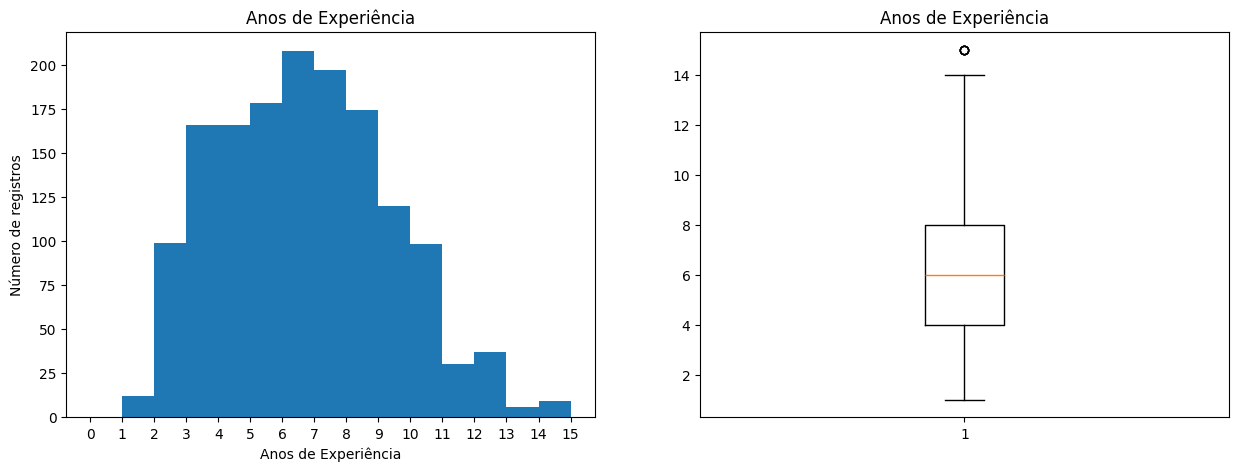

In [23]:
config = HistogramConfig(sr=df_copy['years_of_experience'], bins=list(range(0, 16)), title='Anos de Experiência', x_label='Anos de Experiência')
numeric_feature_hist_box_plots(config)

### Annual salary usd

O salário anual possui uma média de 194.892 dólares por ano, com um alto desvio padrão de 66.506 dólares. O valor mínimo é de 90 mil dólares e o máximo de 384 mil dólares.

O histograma possui uma distribuição assimétrica à direita, mostrando que é mais raro ter salários mais altos.

O Boxplot mostra alguns salários altos como outliers, porém são valores possíveis.

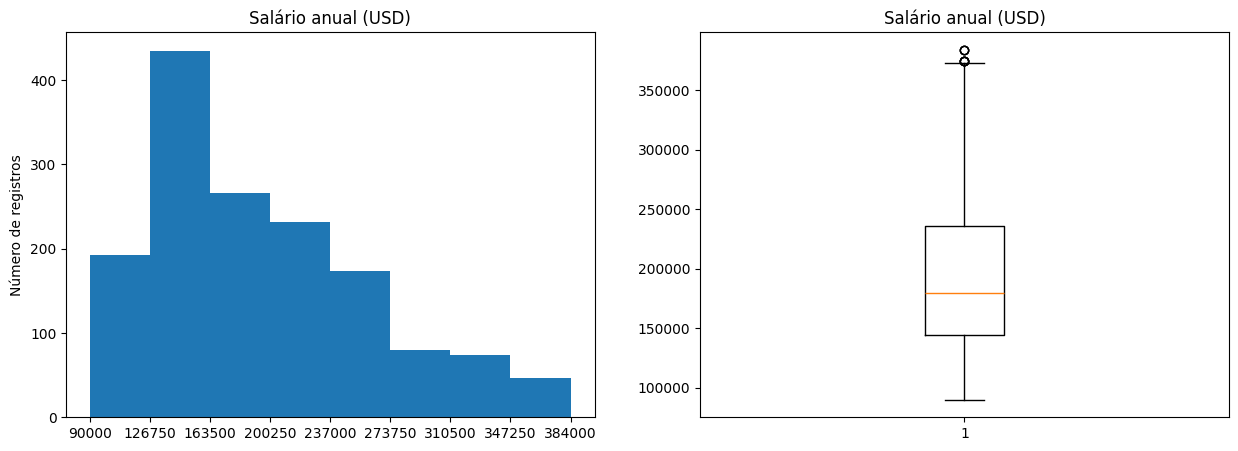

In [33]:
sr = df_copy['annual_salary_usd']
step = int((sr.max() - sr.min())) // 8
config = HistogramConfig(sr=sr, bins=list(range(90000, 384000 + step, step)), title='Salário anual (USD)', x_label='')
numeric_feature_hist_box_plots(config)

### Ai salary premium pct

A média de porcentagem de prêmio salarial é de 10,86 % com mínimo de 3 % e máximo de 18 %, indicando que a área de IA e ML paga melhor do que outras áreas semelhantes, talvez devido a uma alta na demanda por profissionais.

O histograma possui uma distribuição normal, com a maior frequência de porcentagem de prêmio entre 8 e 10 %.

O boxplot indica que não existem outliers.

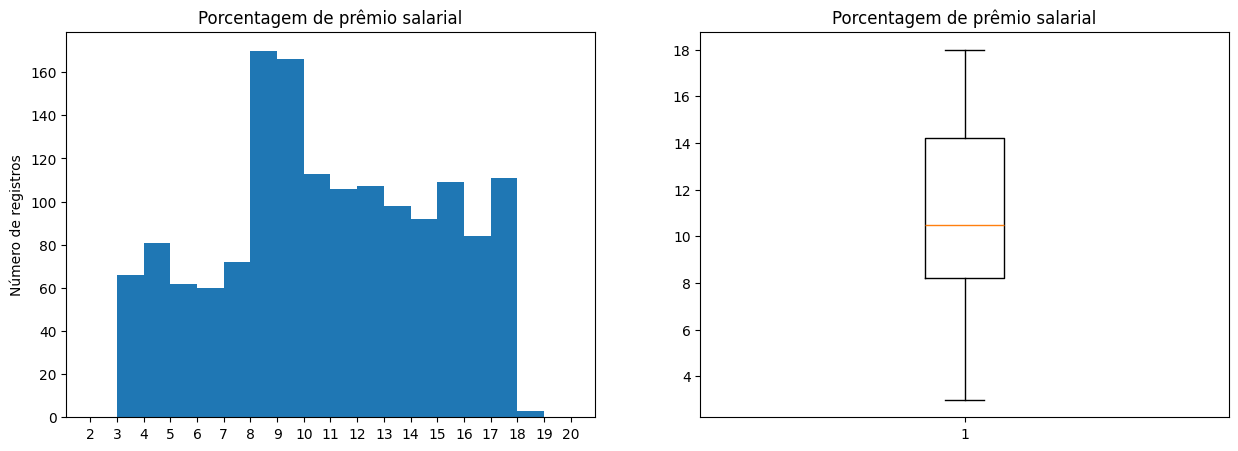

In [40]:
sr = df_copy['ai_salary_premium_pct']
config = HistogramConfig(sr=sr, bins=list(range(2, 21, 1)), title='Porcentagem de prêmio salarial')
numeric_feature_hist_box_plots(config)

### Demand score

Corroborando com o que foi aprendido com o atributo ai_salary_premium_pct, existe uma demanda alta por profissionais de IA, com média de pontuação de demanda de 87,52.

O histograma possui uma distribuição assimétrica à esquerda, com a maior frequência de pontuação entre 95 e 100.

O boxplot não indica existência de outliers.

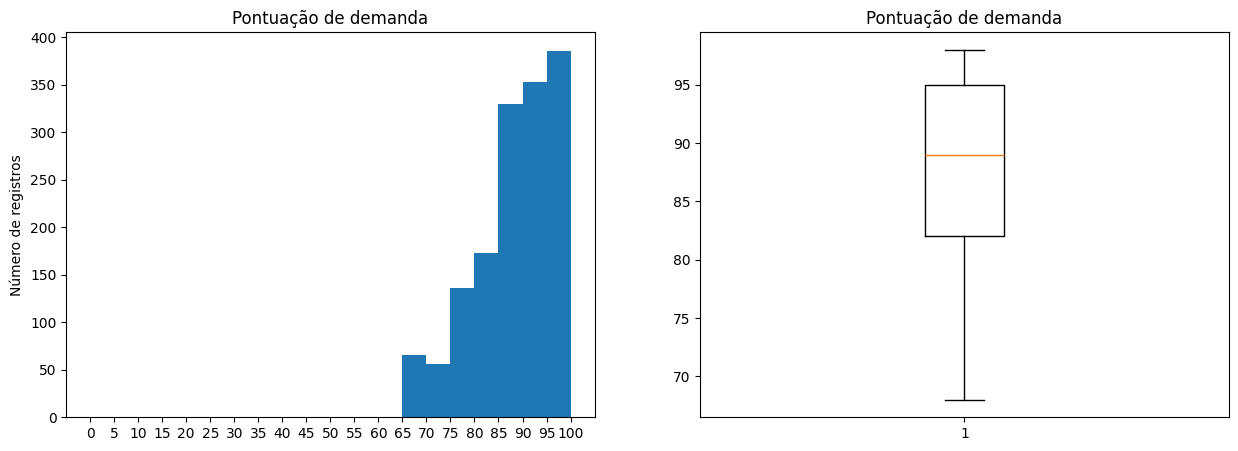

In [41]:
sr = df_copy['demand_score']
config = HistogramConfig(sr=sr, bins=list(range(0, 105, 5)), title='Pontuação de demanda')
numeric_feature_hist_box_plots(config)

### Demand growth yoy pct

Só existem dois anos de registros de anúncios nesse dataset, portanto não é possível inferir muito sobre os dados desse atributo.

O histograma possui uma distribuição assimétrica à direita, indicando que a maior parte dos cargos de IA não sofreu um aumento muito grande na demanda de um ano para outro.

O boxplot indica a existência de outliers, com valores próximos a 100 % no aumento da demanda, que pode ser explicado pelo boom gerado no mercado de IA generativa.

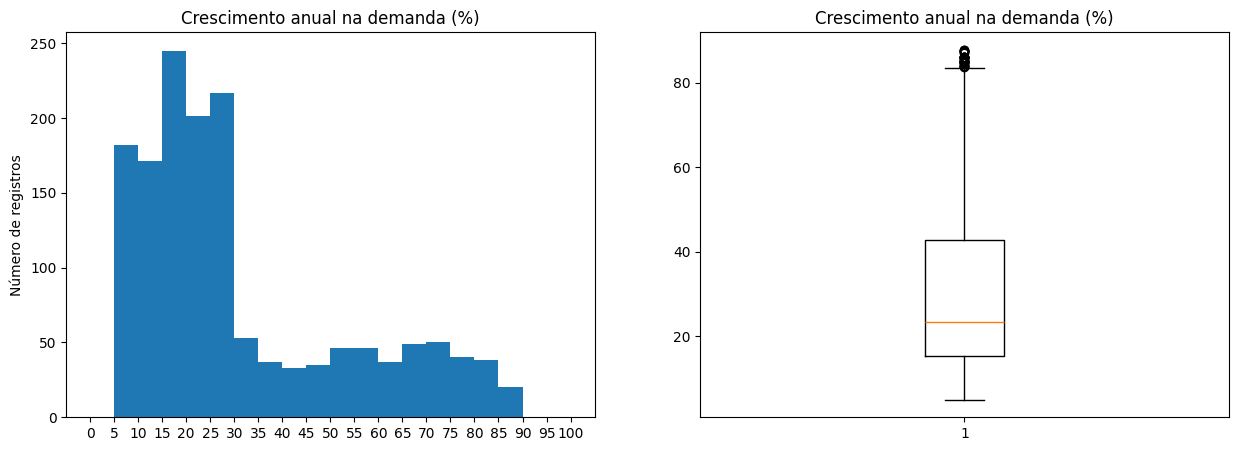

In [43]:
sr = df_copy['demand_growth_yoy_pct']
config = HistogramConfig(sr=sr, bins=list(range(0, 105, 5)), title='Crescimento anual na demanda (%)')
numeric_feature_hist_box_plots(config)

Cargos que tiverem o maior crescimento de demanda no último ano:

In [13]:
df_copy.loc[df_copy['demand_growth_yoy_pct'] >= 80].groupby('job_title').size().sort_values(ascending=False)

job_title
RAG Engineer              9
LLM Engineer              8
NLP Engineer              7
Generative AI Engineer    7
Senior ML Engineer        6
AI Engineer               6
AI Agent Developer        4
Data Scientist            4
MLOps Engineer            4
ML Engineer               3
dtype: int64

### Benefits score 10

A pontuação de benefícios possui média 7,89 com desvio padrão baixo de 1,1, indicando que os anúncios tendem a ofertar bons benefícios aos contratados.

O histograma possui uma distribuição assimétrica à esquerda, com valores de pontuação uniformemente distribuídos entre 6 e 10.

O boxplot não indica a existência de outliers.

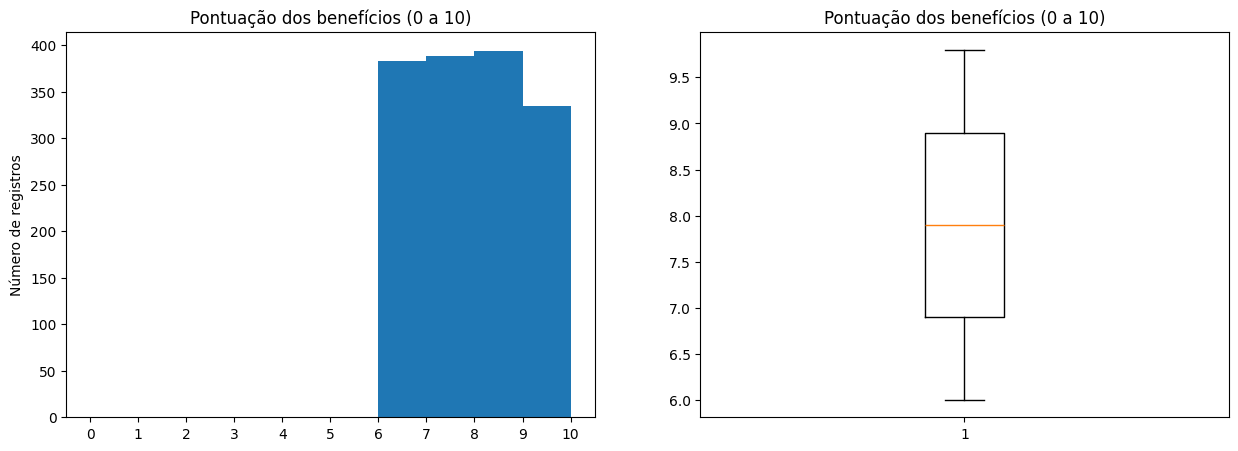

In [44]:
sr = df_copy['benefits_score_10']
config = HistogramConfig(sr=sr, bins=list(range(0, 11)), title='Pontuação dos benefícios (0 a 10)')
numeric_feature_hist_box_plots(config)

## Scatter Plot

A seguir, scatter plot entre as variáveis numéricas.

O maior ponto de interesse é a relação das variáveis com o Annual Salary USD. Visualmente, as variáveis years_of_experience, demand_score e demand_growth_yoy_pct parecem possuir uma correlação positiva com annual salary usd.

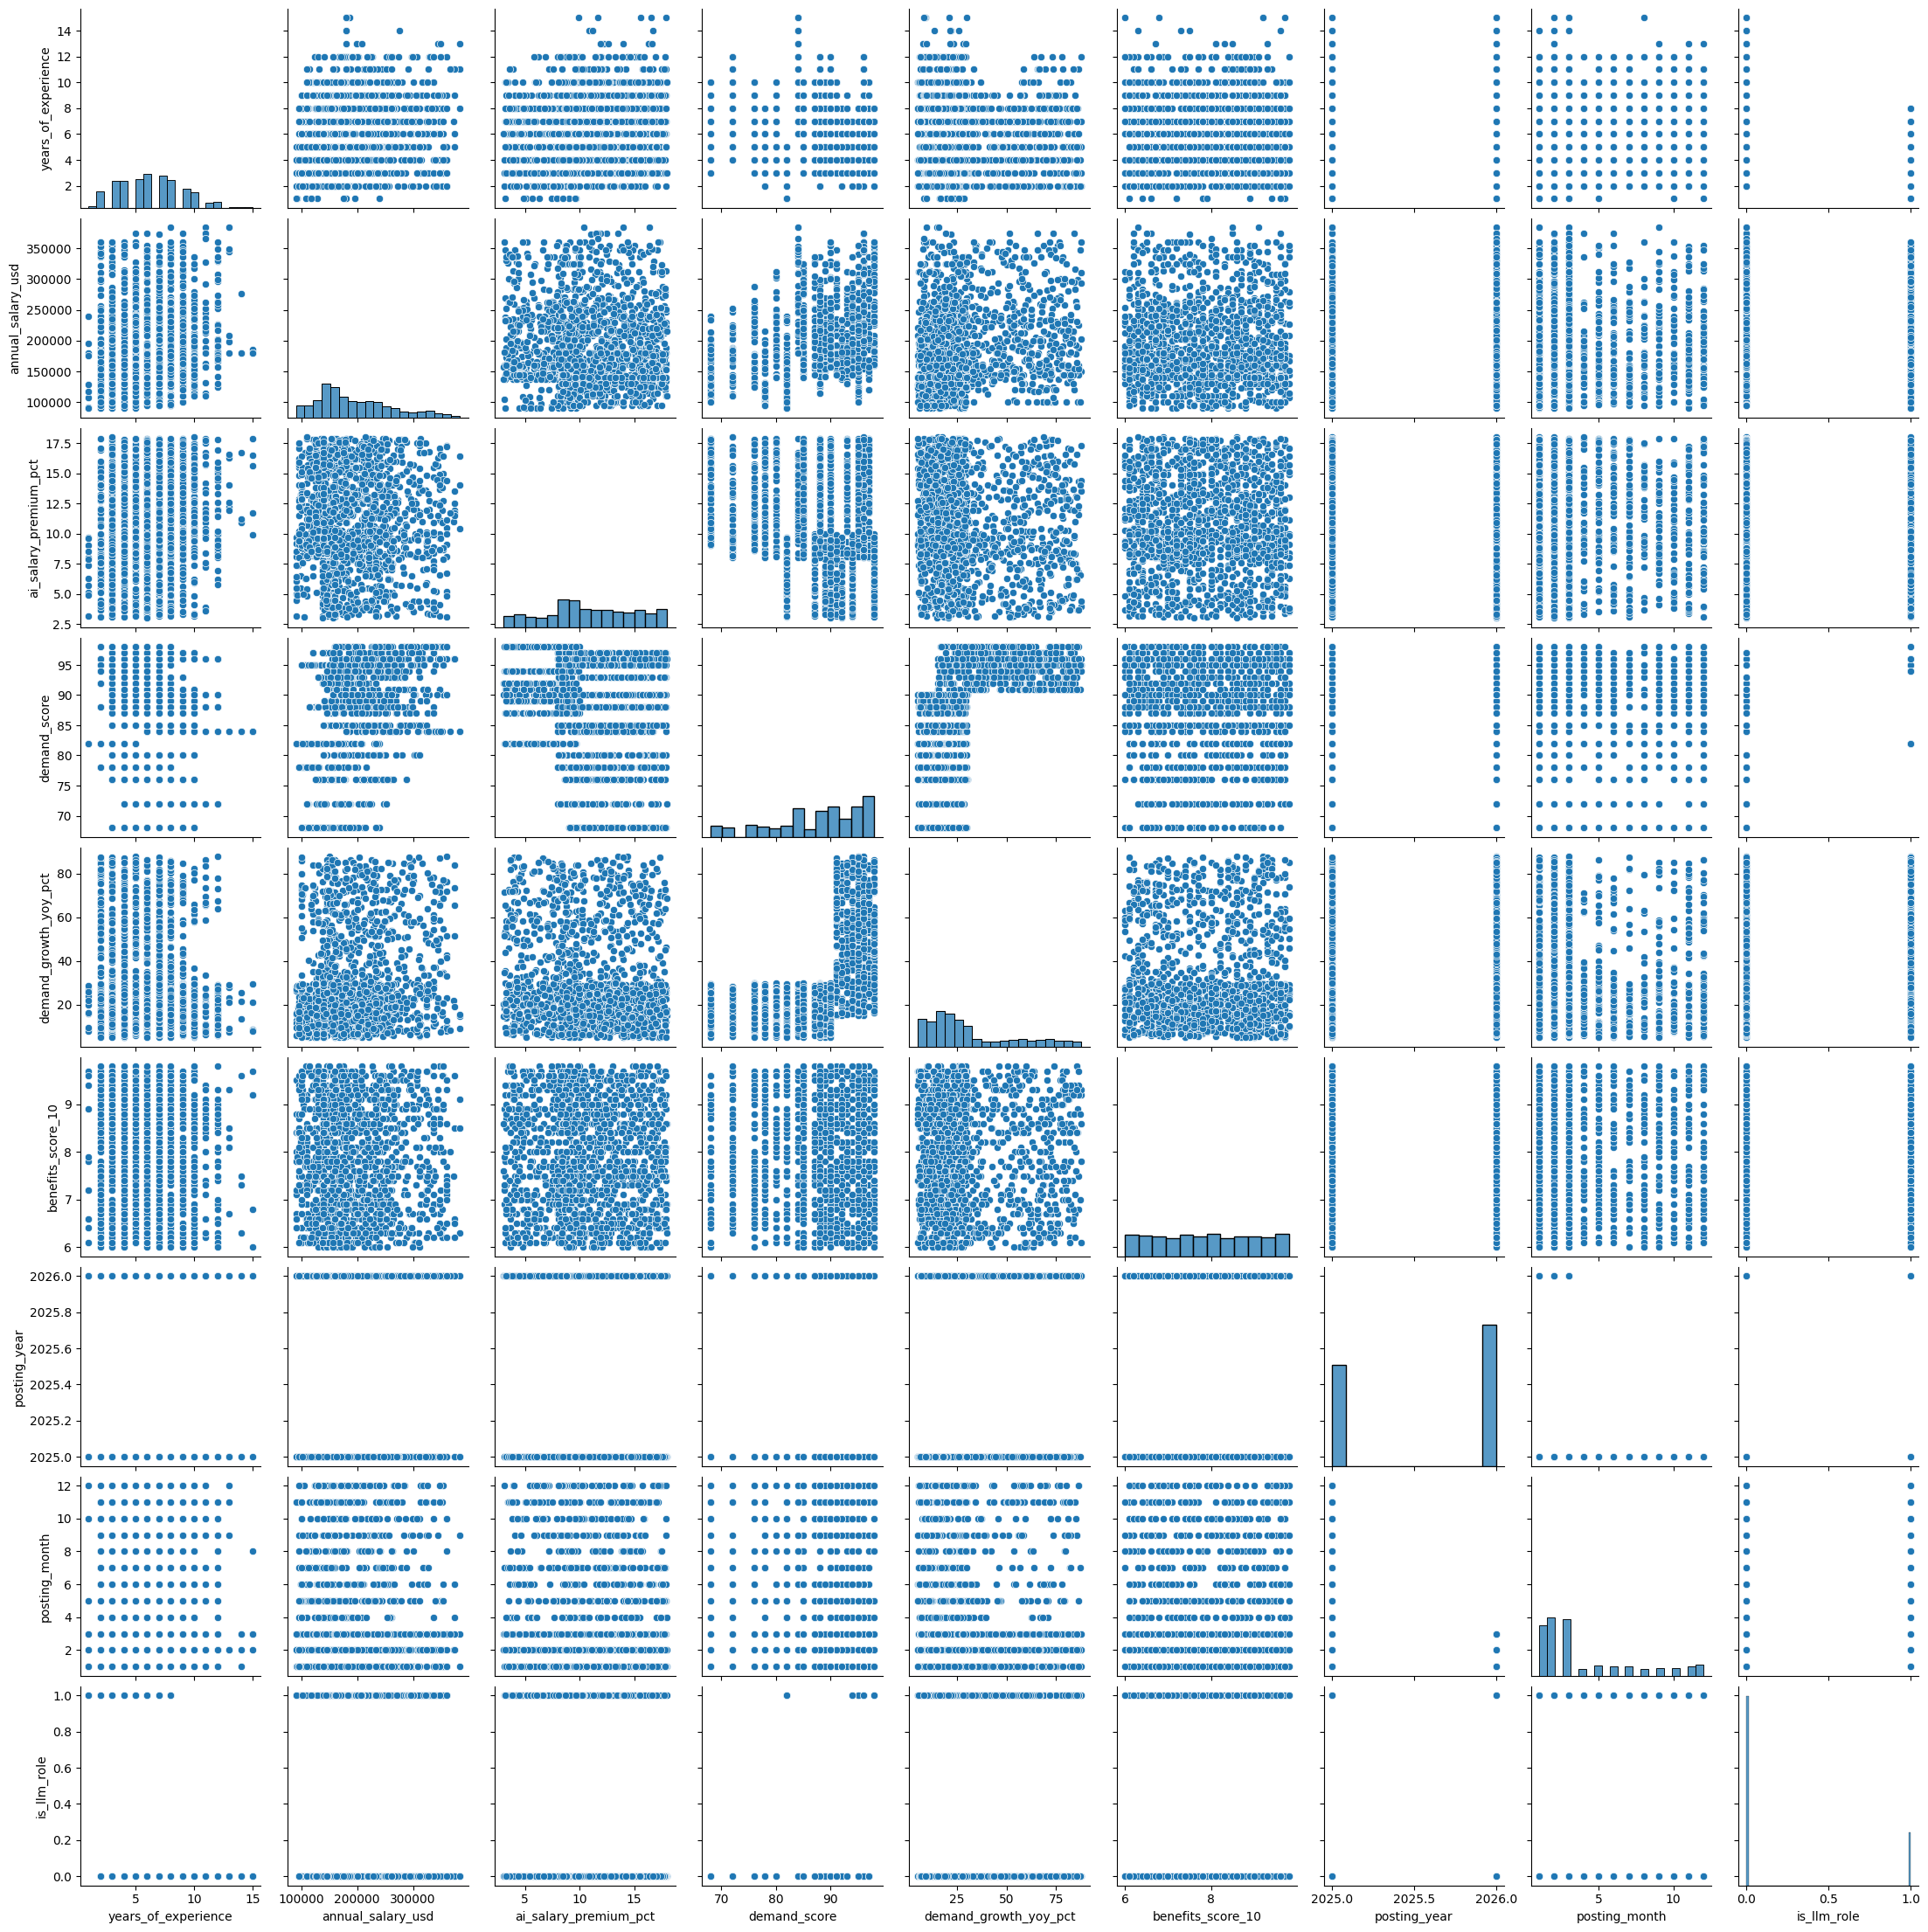

In [45]:
sns.pairplot(df_copy)

## Matrix de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

Pontos de interesse:

- Annual Salary USD possui uma correlação positiva com demand_score e demand_growth_yoy_pct. Possivelmente esse aumento de demanda para certos cargos faz com que o salário aumente.
- Years of Experience possui uma correlação negativa com is_llm_role. Pode-se interpretar que como é um mercado de IA novo, os anúncios exigem menos anos de experiência.
- Demand_Score possui uma correlação positiva com is_llm_role. O boom no mercado de IA voltado a IA generativa deve ter aumentado a demanda por esse cargo.

<Axes: >

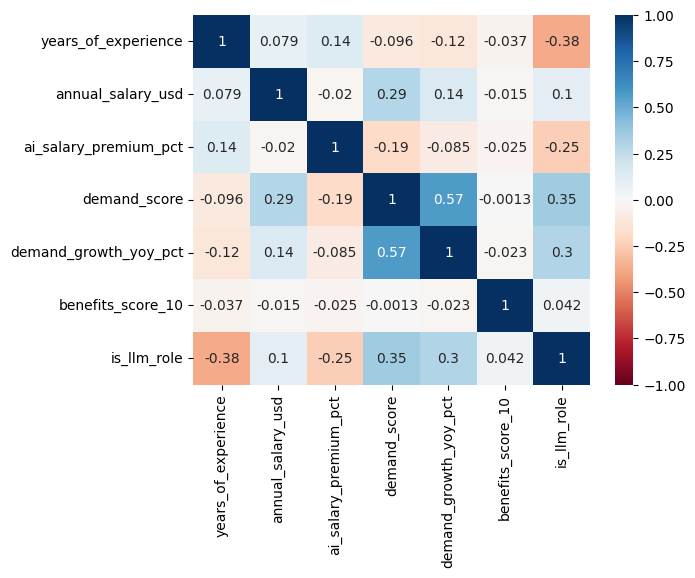

In [47]:
sns.heatmap(data=df_copy.drop(columns=['posting_year', 'posting_month']).corr(numeric_only=True), vmin=- 1, vmax=1, cmap='RdBu', annot=True)

## Análise dos atributos categóricos

Vamos analisar o comportamento das variáveis categóricas. Quando exitir poucos valores distintos no atributo categórico, será utilizado um gráfico de pizza, do contrário, será utilizado gráfico de barras. Além disso, para cada atributo, será usado um density plot com hue para termos uma visualização de como o atributo se relaciona com Annual Salary USD.

In [53]:
def func(pct, allvals):
    '''
    Function from https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_and_donut_labels.html
    '''
    absolute = int(np.round(pct/100.*np.sum(allvals)))
    return f"{absolute:d}\n{pct:.1f}%"


def categoric_feature_pie_density_plot(df: pd.DataFrame, label: str) -> None:
    '''
    Create a pie plot following https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_and_donut_labels.html.
     And a density plot using seaborn with hue=feature.
    '''
    vcmap = plt.get_cmap('tab10', 10)
    sr = df[label]
    group_by = sr.value_counts()
    data, labels = group_by.values.tolist(), group_by.index.to_list()
    color_map = {label: vcmap(i) for i, label in enumerate(labels)}
    color_order = [color_map[label] for label in labels]

    fig, ax = plt.subplots(1, 2, figsize=(20, 5))
    wedges, texts, autotexts = ax[0].pie(data, autopct=lambda pct: func(pct, data), textprops=dict(color="w"), colors=color_order)
    ax[0].legend(wedges, labels,
          title=label.replace('_', ' '),
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))
    plt.setp(autotexts, size=8, weight="bold")
    sns.kdeplot(df, x='annual_salary_usd', hue=label, ax=ax[1], palette=color_map)
    ax[0].set_title(f'{label.replace("_", " ")} distribution')
    fig.show()

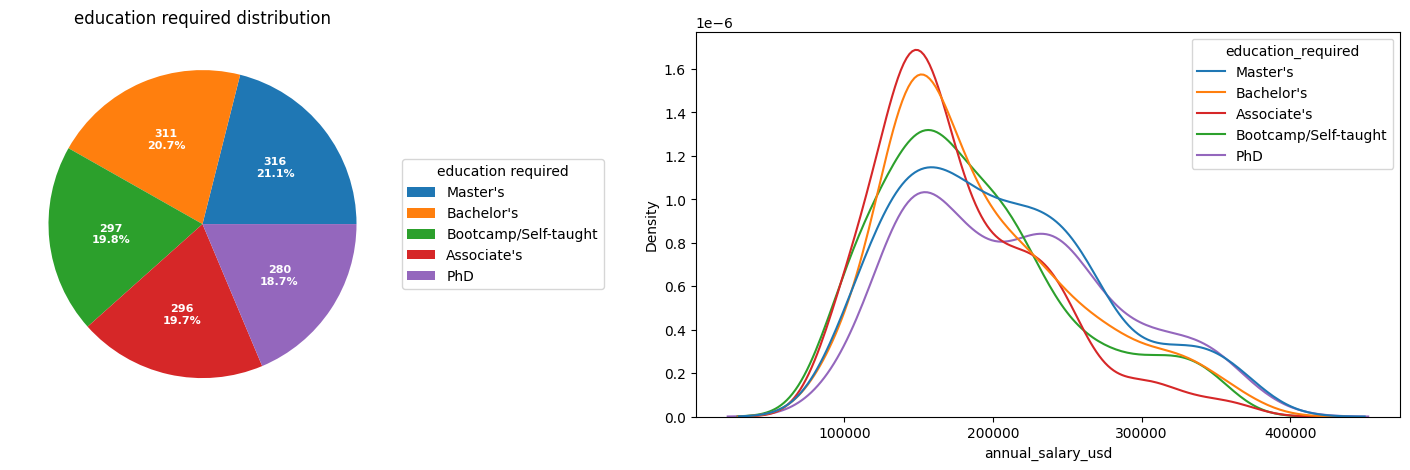

In [54]:
categoric_feature_pie_density_plot(df_copy, 'education_required')

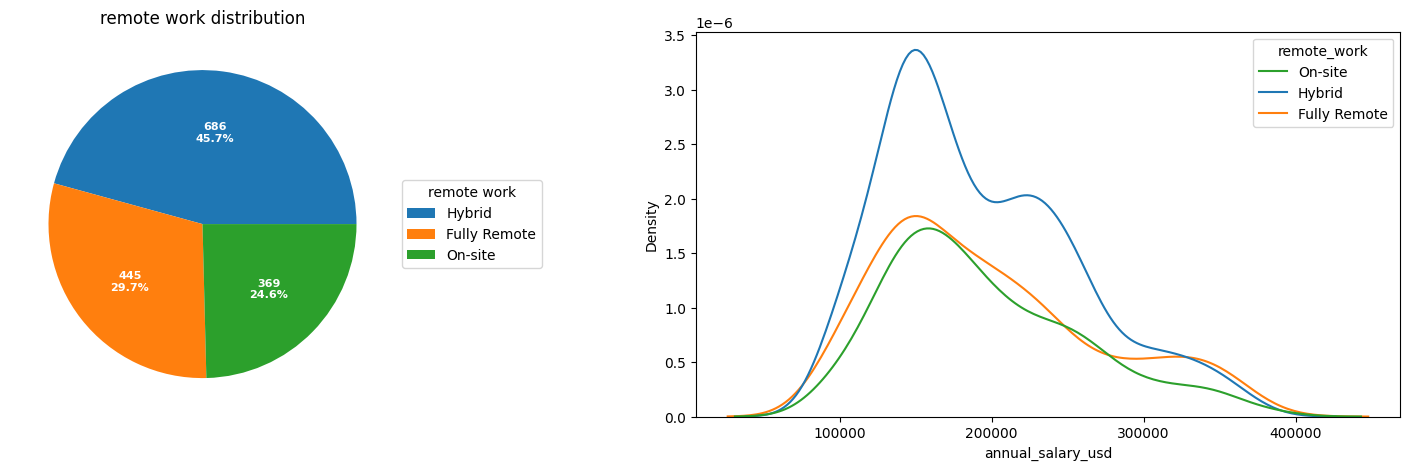

In [57]:
categoric_feature_pie_density_plot(df_copy, 'remote_work')

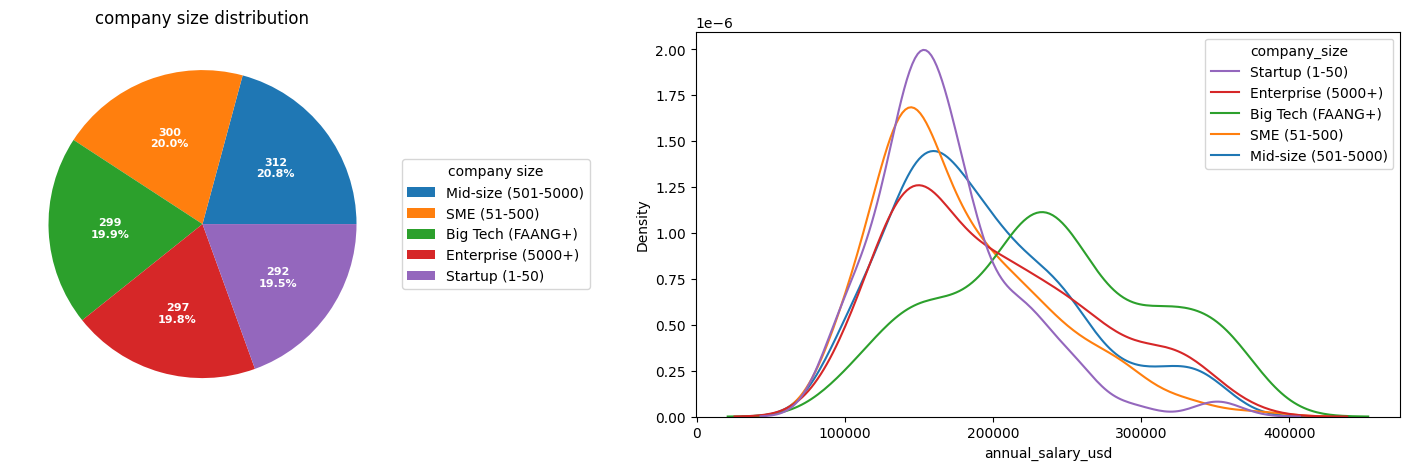

In [58]:
categoric_feature_pie_density_plot(df_copy, 'company_size')

In [49]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_title              1500 non-null   object 
 1   job_category           1500 non-null   object 
 2   experience_level       1500 non-null   object 
 3   years_of_experience    1500 non-null   int64  
 4   education_required     1500 non-null   object 
 5   annual_salary_usd      1500 non-null   float64
 6   city                   1500 non-null   object 
 7   country                1500 non-null   object 
 8   remote_work            1500 non-null   object 
 9   company_size           1500 non-null   object 
 10  industry               1500 non-null   object 
 11  required_skills        1500 non-null   object 
 12  ai_salary_premium_pct  1500 non-null   float64
 13  demand_score           1500 non-null   int64  
 14  demand_growth_yoy_pct  1500 non-null   float64
 15  bene